# <center> Understanding Student Dropouts In The Portugal </center>

# Table of Contents
* [Part 1](#part1)
  * [Importing & Transforming Data](#import)
  * [EDA](#eda)
  * [Outliers](#outliers)
* [Part 2](#part2)
  * [Categorical vs. Categorical Variables](#categ_categ)
  * [Continuous vs. Continuous Variables](#cont_cont)
  * [Binary vs. Binary Variables](#binary_binary)
  * [Binary vs. Continuous Variables](#binary_cont)
* [Part 3](#part3)
* [Part 4](#part4)

<a id='part1'></a>
# Part 1 - Data


<a id='import'></a>
## 1. Importing & Transforming Data

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from itertools import combinations
import phik
import scipy.stats as stats

# Read the CSV file while seperating the data 
unclean_data = pd.read_csv("Portugal_Student_Data.csv", sep = ";")

# Display the first few rows
print(unclean_data.head())

   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance\t  Previous qualification  \
0                             1                       1   
1                             1                       1   
2                             1                       1   
3                             1                       1   
4                             0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2                         

- Removing variables that we won't be needing to predict drop out

Note: Dimensions are still included in our data and won't be seperated. Dimensions are there just to help with analyzing and dividing work.

In [2]:
#Removing columns

df = unclean_data.drop(columns = ["Nacionality", "Curricular units 2nd sem (credited)", 
                                  "Curricular units 2nd sem (enrolled)",
                                  "Curricular units 2nd sem (evaluations)",
                                  "Curricular units 2nd sem (approved)",
                                  "Curricular units 2nd sem (without evaluations)",
                                  "Curricular units 1st sem (without evaluations)",
                                  "Curricular units 1st sem (credited)",
                                  "Curricular units 1st sem (enrolled)",
                                  "Curricular units 1st sem (evaluations)",
                                  "Curricular units 1st sem (approved)"])

print(df.head())

   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance\t  Previous qualification  \
0                             1                       1   
1                             1                       1   
2                             1                       1   
3                             1                       1   
4                             0                       1   

   Previous qualification (grade)  Mother's qualification  \
0                           122.0                      19   
1                           160.0                       1   
2                           122.0                      37   
3   

- Mother and father columns need to be renamed later on for MANOVA
- Encoding Target variable

In [3]:
#Renaming Mother and Father variables
df.rename(columns=lambda x: x.replace("'", "").replace(" ", "_").replace("/", "_"), inplace=True)
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.strip() 

df.rename(columns={
    "Mother's_occupation": "Mother_occupation",
    "Mother's_qualification": "Mother_qualification",
    "Father's_occupation": "Father_occupation",
    "Father's_qualification": "Father_qualification",
    "Daytime/evening attendance/":"Daytime/evening attendance",
    "Curricular_units_1st_sem_(grade)" : "first_sem_grade",
    "Curricular_units_2nd_sem_(grade)": "second_sem_grade"
}, inplace=True)



In [4]:
print(df.columns.tolist())


['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_(grade)', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'first_sem_grade', 'second_sem_grade', 'Unemployment_rate', 'Inflation_rate', 'GDP', 'Target']


In [5]:
df['Target'] = df['Target'].str.strip().str.capitalize()
filter = df[df['Target'] == "Enrolled"].index
df.drop(filter, inplace=True)


In [6]:
mapping = {'Graduate': 0, 'Dropout': 1}
df['Target'] = df['Target'].replace(mapping)


C:\Users\amann\AppData\Local\Temp\ipykernel_18116\2499565689.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Target'] = df['Target'].replace(mapping)


In [7]:
print(df['Target'].unique())


[1 0]


In [8]:
# Applying Kat's Transformations
# Already done Julie's 

df['Admission_grade'] = np.sqrt(df['Admission_grade'])

# for col in ['first_sem_grade', 'second_sem_grade']:
#     max_val = df[col].max()
#     df[col + '_log'] = np.log((max_val + 1) - df[col])

# print(df['Admission_grade'].head())
# print(df['first_sem_grade'].head())
# print(df['second_sem_grade'].head())

In [9]:
df['Average_Sem_Grade'] = (df['first_sem_grade'] + df['second_sem_grade'])/2
print(df['Average_Sem_Grade'])


0        0.000000
1       13.833333
2        0.000000
3       12.914286
4       12.666667
          ...    
4419    13.133333
4420    11.500000
4421    14.206250
4422    12.900000
4423    12.333333
Name: Average_Sem_Grade, Length: 3630, dtype: float64


In [10]:
df['GDP'] = df['GDP'] / 100
print(df['GDP'].head())

df['Inflation_rate'] = df['Inflation_rate'] / 100
print(df['Inflation_rate'].head())

df['Unemployment_rate'] = df['Unemployment_rate'] / 100
print(df['Unemployment_rate'].head())

0    0.0174
1    0.0079
2    0.0174
3   -0.0312
4    0.0079
Name: GDP, dtype: float64
0    0.014
1   -0.003
2    0.014
3   -0.008
4   -0.003
Name: Inflation_rate, dtype: float64
0    0.108
1    0.139
2    0.108
3    0.094
4    0.139
Name: Unemployment_rate, dtype: float64


In [11]:
df['Age_at_enrollment'] = np.log(df['Age_at_enrollment'])

In [12]:

# df = df.drop(columns = [])


<a id='eda'></a>
## 2. EDA

Checking data types and description

In [13]:
#Checking data types to use as a filter to create the correlation matrix
df.dtypes

Marital_status                      int64
Application_mode                    int64
Application_order                   int64
Course                              int64
Daytime_evening_attendance          int64
Previous_qualification              int64
Previous_qualification_(grade)    float64
Mothers_qualification               int64
Fathers_qualification               int64
Mothers_occupation                  int64
Fathers_occupation                  int64
Admission_grade                   float64
Displaced                           int64
Educational_special_needs           int64
Debtor                              int64
Tuition_fees_up_to_date             int64
Gender                              int64
Scholarship_holder                  int64
Age_at_enrollment                 float64
International                       int64
first_sem_grade                   float64
second_sem_grade                  float64
Unemployment_rate                 float64
Inflation_rate                    

In [14]:
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_(grade),Mothers_qualification,Fathers_qualification,Mothers_occupation,...,Scholarship_holder,Age_at_enrollment,International,first_sem_grade,second_sem_grade,Unemployment_rate,Inflation_rate,GDP,Target,Average_Sem_Grade
count,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,...,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000
mean,1.184298,18.421763,1.750138,8853.980992,0.887603,4.532231,132.920606,19.986226,22.571625,10.138567,...,0.266942,3.112953,0.023691,10.534860,10.036155,0.116304,0.012316,-0.000093,0.391460,10.285507
std,0.613009,17.358595,1.333831,2068.760082,0.315897,10.024134,13.238373,15.585278,15.275453,23.315697,...,0.442423,0.273113,0.152107,5.057694,5.481742,0.026677,0.013849,0.022600,0.488144,5.062926
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,0.000000,...,0.000000,2.833213,0.000000,0.000000,0.000000,0.076000,-0.008000,-0.040600,0.000000,0.000000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,2.000000,3.000000,4.000000,...,0.000000,2.944439,0.000000,11.000000,10.517857,0.094000,0.003000,-0.017000,0.000000,10.800000
50%,1.000000,17.000000,1.000000,9254.000000,1.000000,1.000000,133.100000,19.000000,19.000000,5.000000,...,0.000000,2.995732,0.000000,12.341429,12.333333,0.111000,0.014000,0.003200,0.000000,12.333333
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,37.000000,37.000000,9.000000,...,1.000000,3.218876,0.000000,13.500000,13.500000,0.139000,0.026000,0.017900,1.000000,13.400000
max,6.000000,57.000000,6.000000,9991.000000,1.000000,43.000000,190.000000,44.000000,44.000000,194.000000,...,1.000000,4.248495,1.000000,18.875000,18.571429,0.162000,0.037000,0.035100,1.000000,18.283654


Checking for NA values
- Appears to have none

In [15]:
print(df.isnull().sum())

Marital_status                    0
Application_mode                  0
Application_order                 0
Course                            0
Daytime_evening_attendance        0
Previous_qualification            0
Previous_qualification_(grade)    0
Mothers_qualification             0
Fathers_qualification             0
Mothers_occupation                0
Fathers_occupation                0
Admission_grade                   0
Displaced                         0
Educational_special_needs         0
Debtor                            0
Tuition_fees_up_to_date           0
Gender                            0
Scholarship_holder                0
Age_at_enrollment                 0
International                     0
first_sem_grade                   0
second_sem_grade                  0
Unemployment_rate                 0
Inflation_rate                    0
GDP                               0
Target                            0
Average_Sem_Grade                 0
dtype: int64


In [16]:
# print(df["1st_sem_grade"].head(50))

# print(df["2nd_sem_grade"].head(50))

Standarizing variables because predictive modeling is sensitive to scaling
- Grading scale: https://withportugal.com/en/blog/ensino-superior-2024

In [17]:
# Admission grade is out of 200 in Portugal
# Standardizing will help both the audience understand and modeling results
# df['Admission_grade'] = df['Admission_grade']
# print(df['Admission_grade'].head())

# # Doing the same for prev qualification
# df['Previous_qualification_(grade)'] = df['Previous_qualification_(grade)']
# print(df['Previous_qualification_(grade)'].head())

#renaming the same column
df.rename(columns={'Previous_qualification_(grade)': 'Previous_qualification_grade'},
           inplace=True)


Visualizing the distribution of variables

<function matplotlib.pyplot.show(close=None, block=None)>

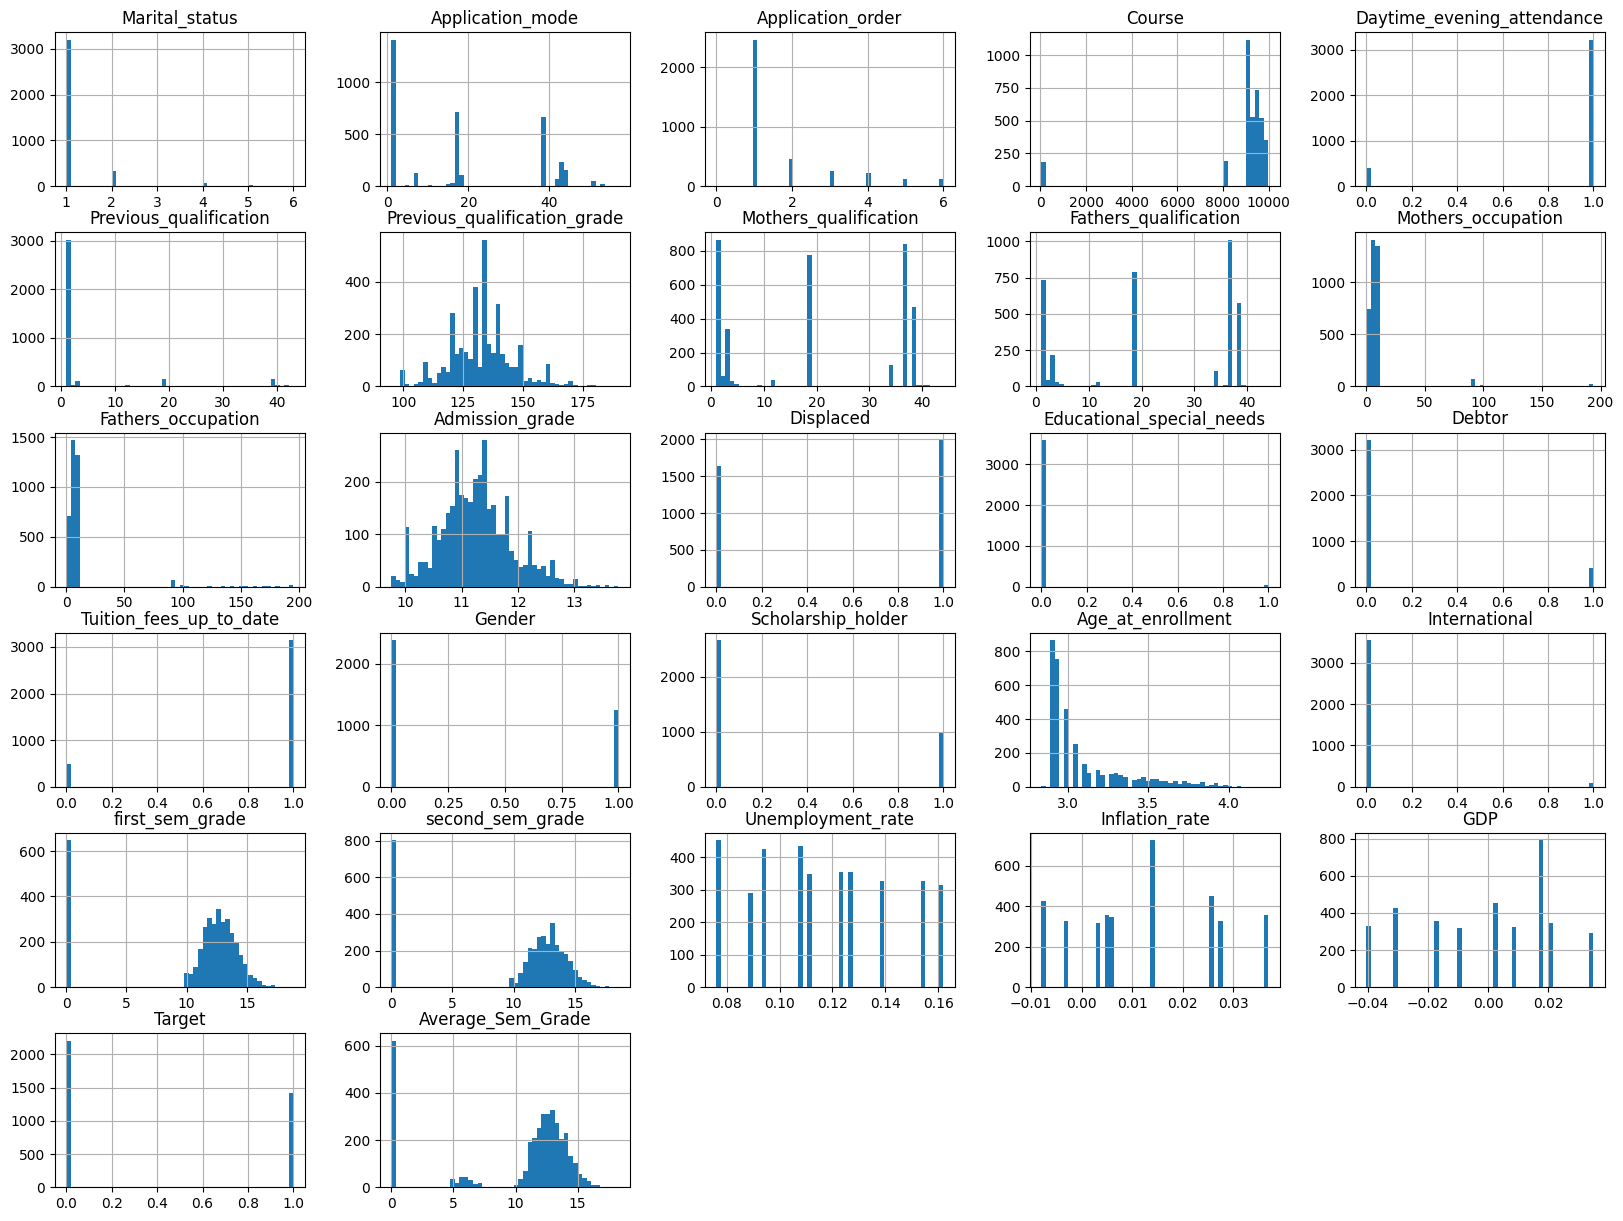

In [18]:
df[df.columns].hist(bins= 50, figsize=(20,15))
plt.show

Transforming Age at enrollment

In [19]:
# age is skewed to the right so we will take the log

df["Age_at_enrollment"] = np.log(df["Age_at_enrollment"])

print(df["Age_at_enrollment"].head(20))


0     1.097189
1     1.079918
2     1.079918
3     1.097189
4     1.336753
5     1.364055
6     1.061385
7     1.128508
8     1.113344
9     1.061385
10    1.061385
11    1.061385
12    1.079918
13    1.113344
14    1.061385
15    1.097189
17    1.061385
18    1.097189
20    1.113344
22    1.061385
Name: Age_at_enrollment, dtype: float64


<a id='outliers'></a>
## 3. Outliers

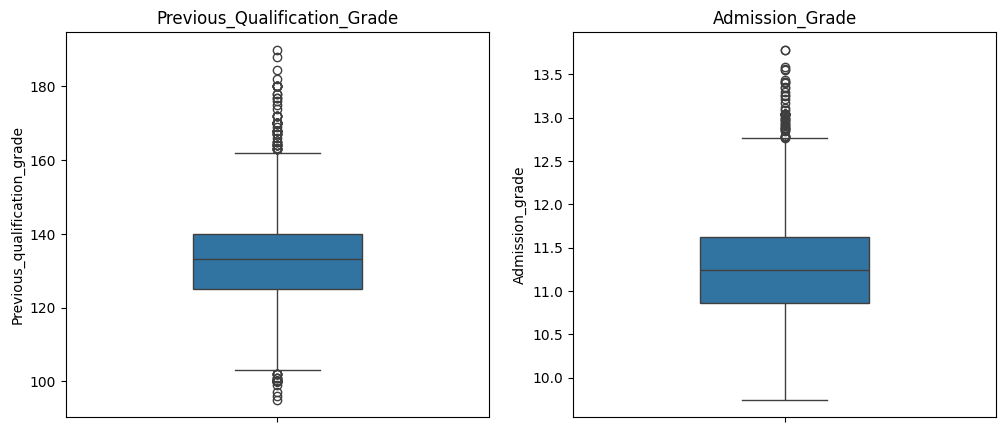

In [20]:
# Prev and Admission Grades

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot boxplots on each subplot
sns.boxplot(y=df['Previous_qualification_grade'], ax=axes[0], width = 0.4)
sns.boxplot(y=df['Admission_grade'], ax=axes[1], width = 0.4)

# Set titles for each subplot
axes[0].set_title('Previous_Qualification_Grade')

axes[1].set_title('Admission_Grade')



plt.show()

Checking for outliers

- No signs of outliers in grades

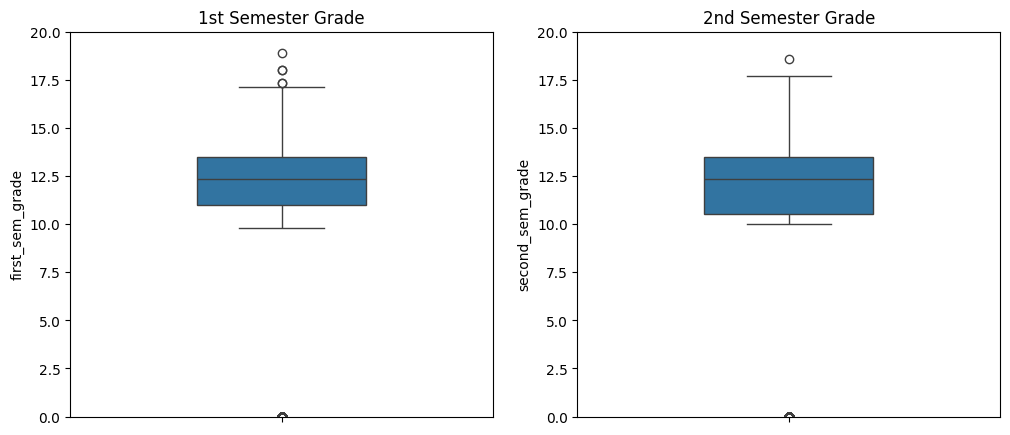

In [21]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot boxplots on each subplot
sns.boxplot(y=df['first_sem_grade'], ax=axes[0], width = 0.4)
sns.boxplot(y=df['second_sem_grade'], ax=axes[1], width = 0.4)

# Set titles for each subplot
axes[0].set_title('1st Semester Grade')
axes[0].set_ylim(0, 20)

axes[1].set_title('2nd Semester Grade')
axes[1].set_ylim(0, 20)


plt.show()

- Both unemployment and inflation rates at the year of the student's interview seem not to have any dangerous outliers. The negative inflation rates indicate periods of deflation.

C:\Users\amann\AppData\Local\Temp\ipykernel_18116\1336401053.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_dict.values(), labels=data_dict.keys())


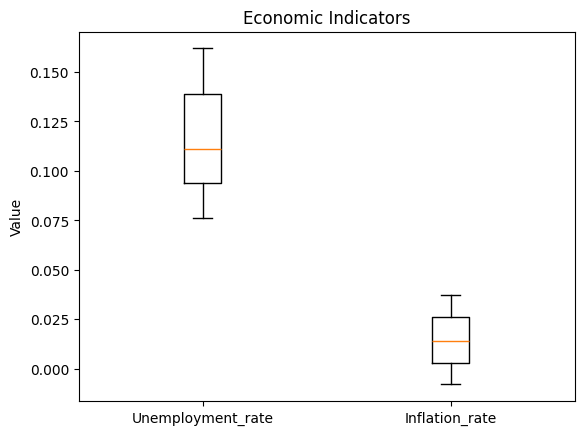

In [22]:
data_dict = {
    "Unemployment_rate": df["Unemployment_rate"],
    "Inflation_rate": df["Inflation_rate"]
}

# Creating the boxplot
plt.boxplot(data_dict.values(), labels=data_dict.keys())
plt.title("Economic Indicators")
plt.ylabel("Value")

plt.show()


Boxplot for Age
- outliers seem normal for the log(age)

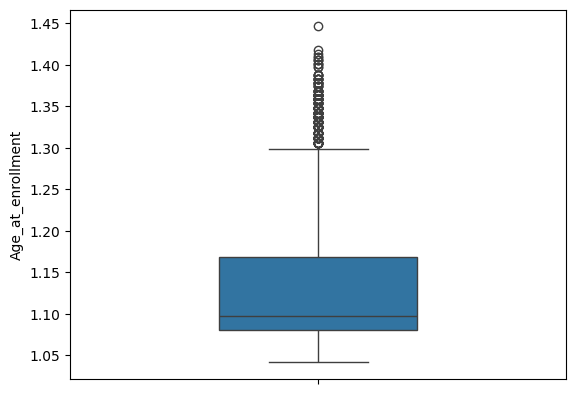

In [23]:
sns.boxplot(y=df['Age_at_enrollment'], width = 0.4)

# plt.ylim(- 0.50, -0.20)
plt.show()

Boxplot for GDP
- no apparent outliers

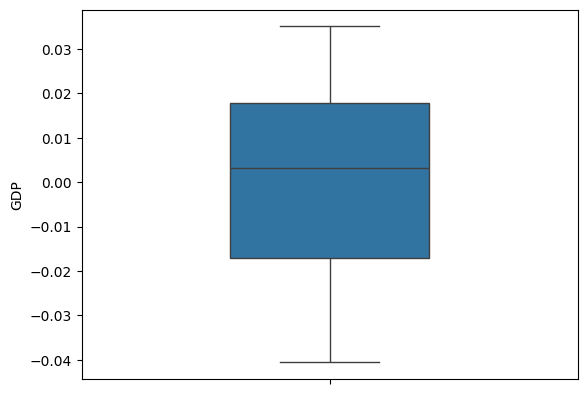

In [24]:
sns.boxplot(y=df['GDP'], width = 0.4)

plt.show()

<a id='part2'></a>
# Part 2 - Correlation

Comparing different data types 

https://stackoverflow.com/questions/42661871/how-to-find-correlation-in-a-mixed-data-including-continuous-category-and-date

Created variables:
* cont_df
* binary_df
* nominal_df

<a id='categ_categ'></a>
## 1. Categorical vs Categorical Relationship

- Use Chi square test https://www.geeksforgeeks.org/python-pearsons-chi-square-test/#

In [25]:
# Step 1: Identify binary columns (0/1 only)
binary_cols = [col for col in df.columns if set(df[col].dropna().unique()) <= {0, 1}]
binary_df = df[binary_cols]

# Remove 'Target' if present
if 'Target' in binary_df.columns:
    binary_df = binary_df.drop('Target', axis=1)

# Step 2: Get nominal columns as int64 excluding binary ones
nominal_df = df.select_dtypes(include=['int64']).drop(columns=binary_cols)

print("Binary columns:", binary_df.columns.tolist())
print("Nominal columns (after removing binary):", nominal_df.columns.tolist())


Binary columns: ['Daytime_evening_attendance', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'International']
Nominal columns (after removing binary): ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Previous_qualification', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation']


This fucntion will create a table that has both chi2 and cramer's V. Chi-2 tells you significance of variable meanwhile Cramer's V measures the association strength between 0 - 1. A value of 0 = no association and 1 = strong association.

In [26]:
def run_chi2_with_cramers_v(nominal_df, categorical_vars, alpha=0.05):
    results = []

    for var1, var2 in combinations(categorical_vars, 2):
        table = pd.crosstab(nominal_df[var1], nominal_df[var2])
        try:
            stat, p, dof, expected = chi2_contingency(table)
            n = table.sum().sum()
            k = min(table.shape)
            cramers_v = np.sqrt(stat / (n * (k - 1))) if k > 1 else np.nan
            results.append({
                "Variable 1": var1,
                "Variable 2": var2,
                "Chi2 Stat": round(stat, 2),
                "p-value": p,
                "Significance": p < 0.05,
                "Cramer's V": round(cramers_v, 3)
            })
        except Exception as e:
            results.append({
                "Variable 1": var1,
                "Variable 2": var2,
                "Error": str(e)
            })

    return pd.DataFrame(results)

# Add a significance interpretation column
def interpret_significance(row):
    if row["Cramer's V"] <= 0.20:
        return "Weak"
    if row["Cramer's V"] <= 0.60:
        return "Moderate"
    if row["Cramer's V"] <= 0.80:
        return "Strong"
    else:
        return "Very Strong"

In this section, we want ot focus on two columns: Significance and Assosciation Strength
<br>
Any variable with a non significant relationship and a weak association strength might want to be looked into.
* In row 7, there is a non significant relationship between marital status and fathers occupation. The Cramer's V score is also weak. This makes it a strong candidate to have either removed based on their relationships with other variables.
* in rows 19 & 20, there is no significant relationship between application order and mothers and fathers occupation. There's also a weak Crammer's V which makes either variables candidate for removal since they are probably correlated together.

In [27]:
# Step 2: Define your nominal columns
nominal_columns = [ 
    "Marital_status", 
    "Application_mode",
    "Application_order",
    "Course",
    "Previous_qualification",
    "Mothers_qualification",
    "Fathers_qualification",
    "Mothers_occupation", 
    "Fathers_occupation",
    
]


# Step 3: Run chi-squared and Cramér's V
chi2_cramer_results = run_chi2_with_cramers_v(nominal_df, nominal_columns)

#adding the keep or remove column:

chi2_cramer_results['Association Strength'] = chi2_cramer_results.apply(interpret_significance, axis=1)
chi2_cramer_results

,Variable 1,Variable 2,Chi2 Stat,p-value,Significance,Cramer's V,Association Strength
0,Marital_status,Application_mode,996.48,1.831588e-155,True,0.234,Moderate
1,Marital_status,Application_order,131.72,1.044463e-14,True,0.085,Weak
2,Marital_status,Course,570.70,3.874775e-75,True,0.177,Weak
3,Marital_status,Previous_qualification,530.93,1.011272e-67,True,0.171,Weak
4,Marital_status,Mothers_qualification,435.47,4.865850e-32,True,0.155,Weak
5,Marital_status,Fathers_qualification,327.32,8.602946e-13,True,0.134,Weak
6,Marital_status,Mothers_occupation,193.65,1.818781e-03,True,0.103,Weak
7,Marital_status,Fathers_occupation,210.41,3.829865e-01,False,0.108,Weak
8,Application_mode,Application_order,781.22,3.333499e-105,True,0.189,Weak
9,Application_mode,Course,1890.41,6.859661e-240,True,0.180,Weak


<a id='cont_cont'></a>
## 2. Continuous vs Continuous Relationship


- Economic factors like GDP, inflation and unemployment have no relation with grades and age. Meanwhile, previous qualification grade and admission have a strong positive relationship, log(age of enrollment) and grades have a weak negative relationship, and log(age of enrollment) with both economic factors and age has no trend. I would suggest to remove all economic factors and GDP from the model for a better fit.

In [28]:
# Selecting continous data (just for correlation usage)
cont_df = df.select_dtypes(include=['float64'])
print(cont_df.head())


   Previous_qualification_grade  Admission_grade  Age_at_enrollment  \
0                         122.0        11.282730           1.097189   
1                         160.0        11.937336           1.079918   
2                         122.0        11.171392           1.079918   
3                         122.0        10.936178           1.097189   
4                         100.0        11.895377           1.336753   

   first_sem_grade  second_sem_grade  Unemployment_rate  Inflation_rate  \
0         0.000000          0.000000              0.108           0.014   
1        14.000000         13.666667              0.139          -0.003   
2         0.000000          0.000000              0.108           0.014   
3        13.428571         12.400000              0.094          -0.008   
4        12.333333         13.000000              0.139          -0.003   

      GDP  Average_Sem_Grade  
0  0.0174           0.000000  
1  0.0079          13.833333  
2  0.0174           0.000000 

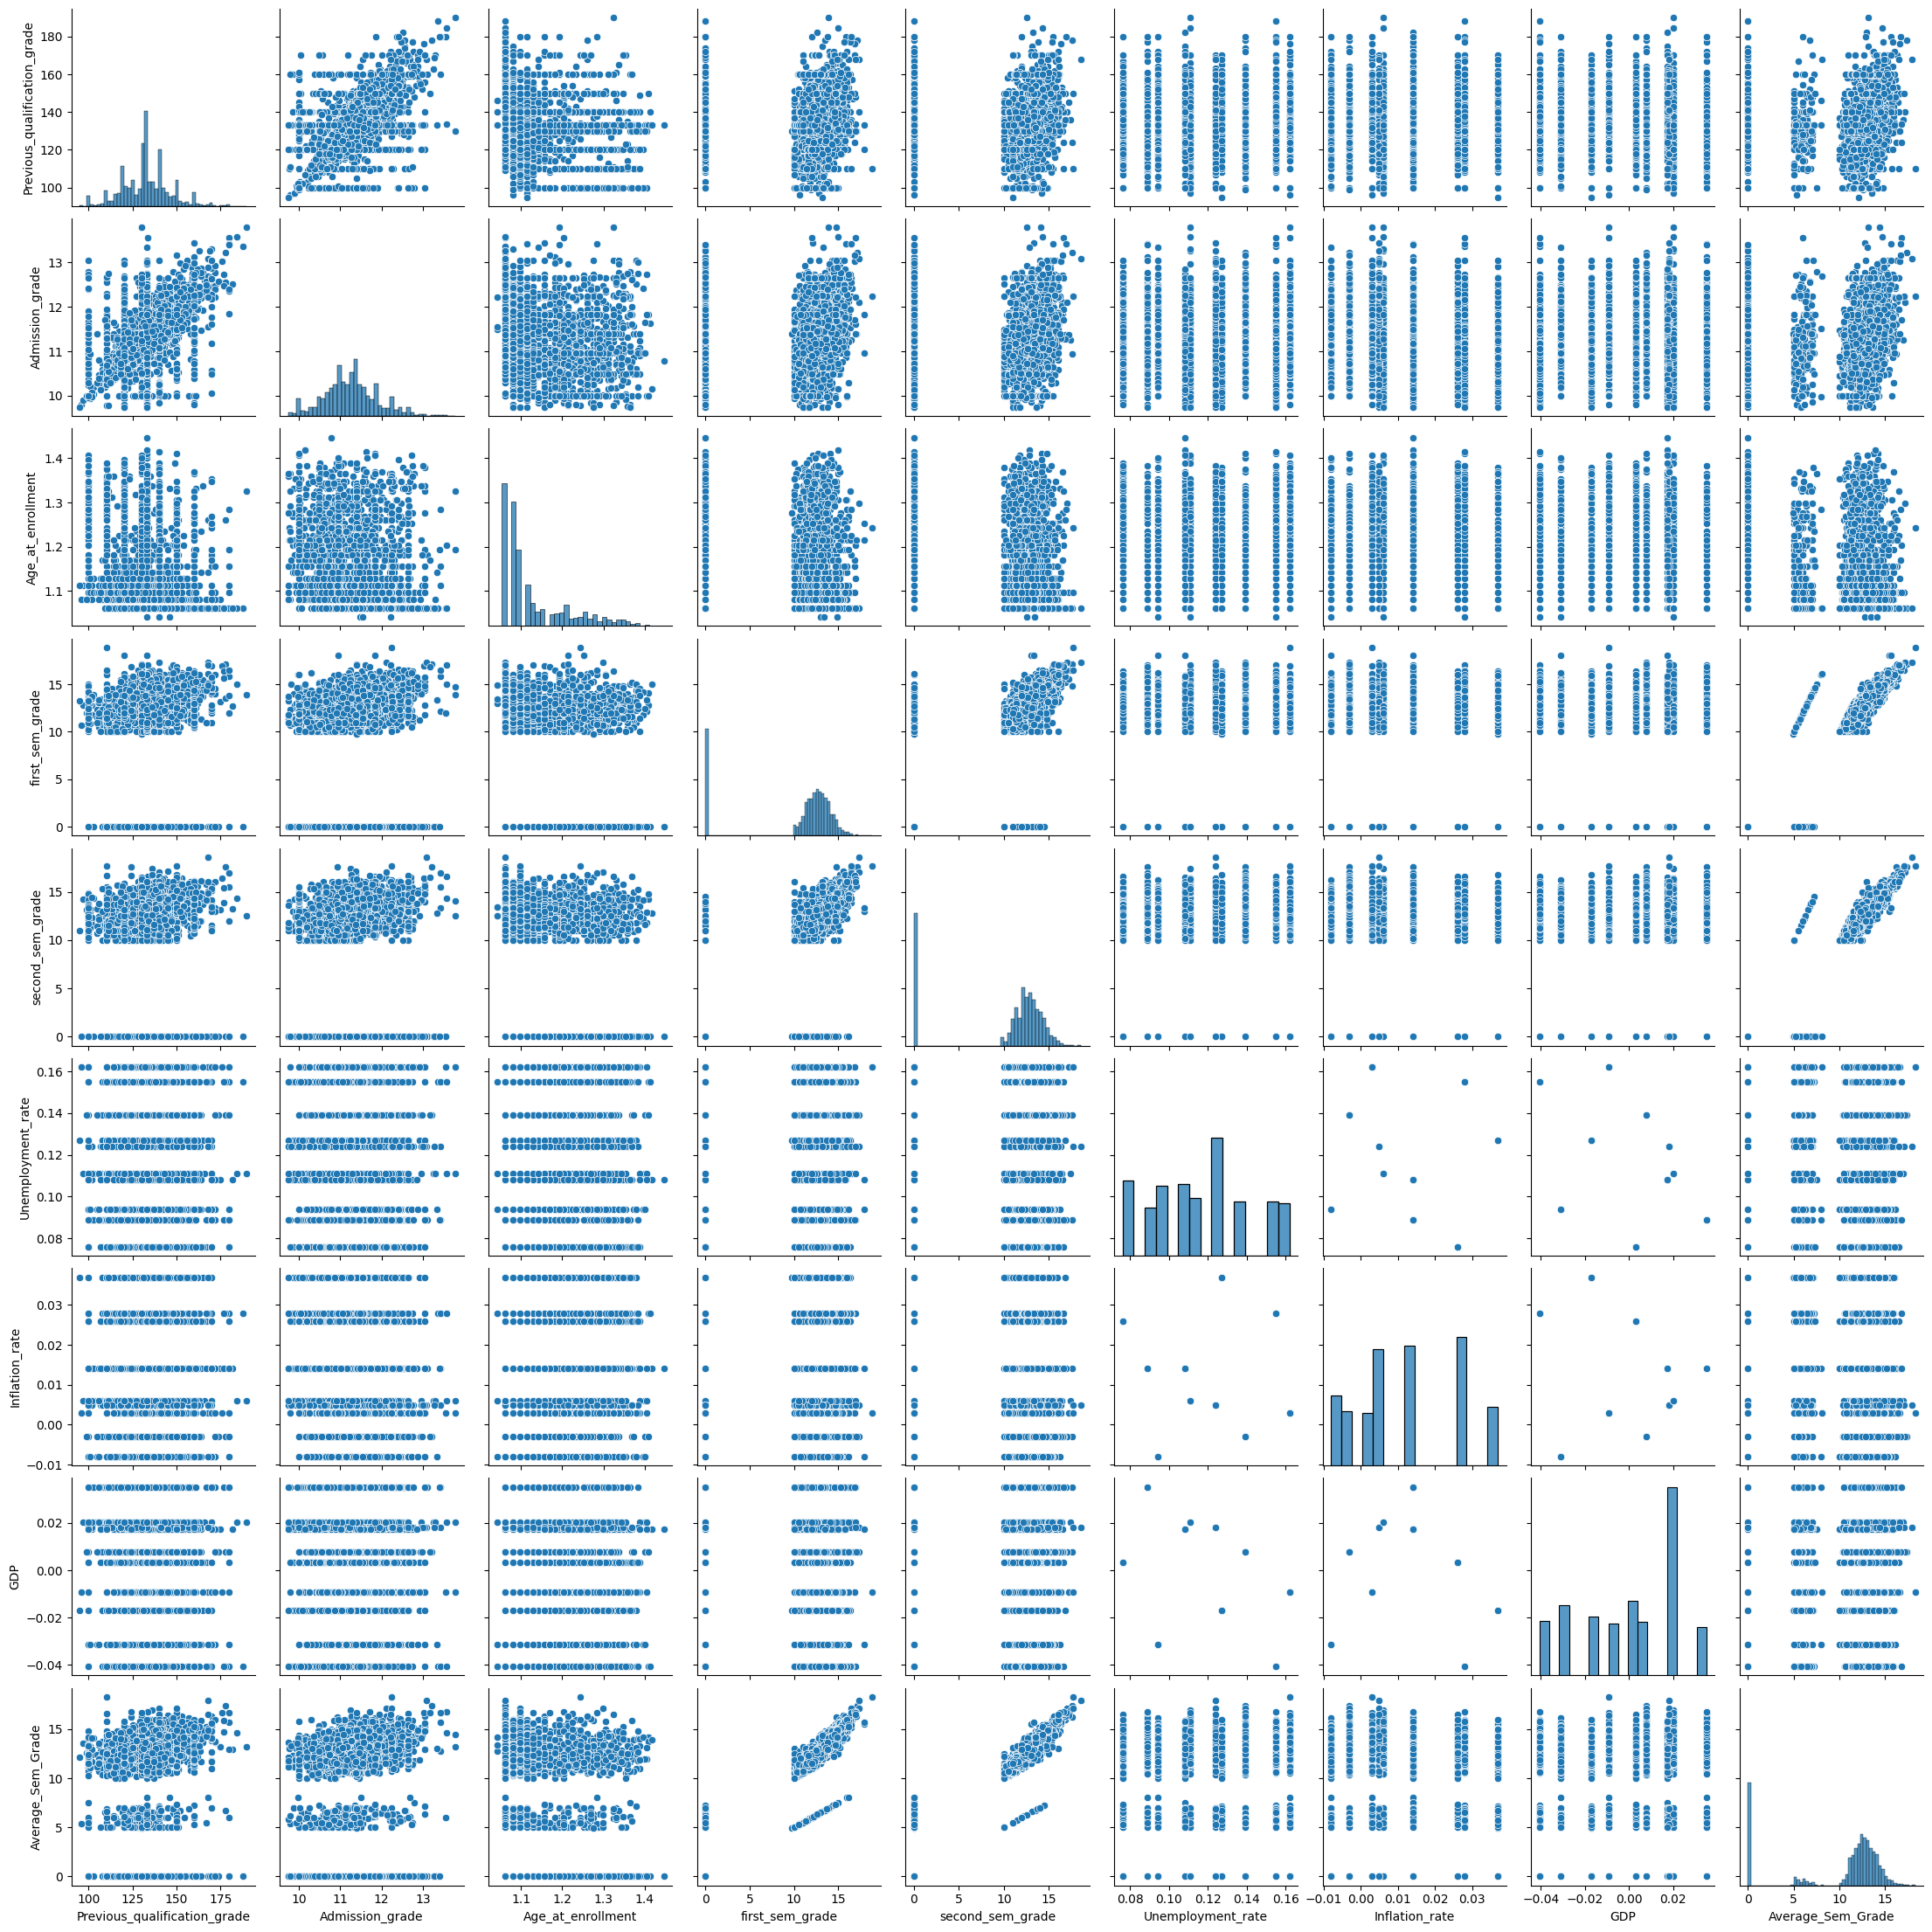

In [29]:
cont_df
sns.pairplot(cont_df)

- Since the graph suggests no relationship between unemployment rate, inflation rate, GDP with other variables, we can check the correlation between them all.
- unemployment rate, inflation rate and GDP all have a very weak correlation score too which means they should taken into consideration for multicollinearity.
<br></br>
- First and sec semester grades have a binomial somewhat positive relationship with the other variables.

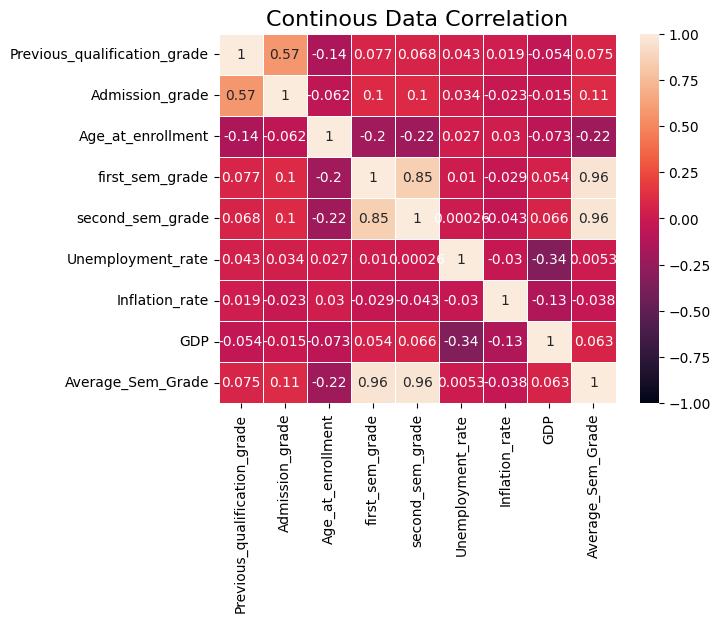

In [30]:
# Matrix plot of continous variables
    # Categorical variables contain numbers from 1 up to almost 30
    # Binary variables can be included in matrix plots but not nominal variables like metioned
    # Because Pearson's correlation assumes numeric meaning and linear meaning

tc = cont_df.corr()
sns.heatmap(tc, 
            annot = True, 
            vmin = -1,
            vmax = 1,
            linewidths = 0.5)

plt.title ("Continous Data Correlation", fontsize = 16)
plt.show()

Checking if there is a relationship between grades and a student dropping out.

Among students whose first semester grade is not zero, only ~28.5% dropped out.

Among those whose first semester grade is zero, a massive ~88.1% dropped out.

* Same can be repeated for second semester grades

<a id='cont_categ'></a>
## 3. Continuous vs Categorical Relationship


- https://psiaims.github.io/CAMIS/python/MANOVA.html

- All variables seam to have an somewhat okay significant level. You can tell that by looking at the p-value which is less than our standard 0.05, which means the effect is statistically significant. 

- The closer Wilk's lambda is to zero, the weaker the group differences are.

- The MANOVA table suggests to remove: Course, Previous_qualification, Father_qualification, Mother_occupation,Father_occupation. We can verify these results by checking the ANOVA between each variable for the continuous variables and categorical variables.

In [31]:
print(cont_df.head())

   Previous_qualification_grade  Admission_grade  Age_at_enrollment  \
0                         122.0        11.282730           1.097189   
1                         160.0        11.937336           1.079918   
2                         122.0        11.171392           1.079918   
3                         122.0        10.936178           1.097189   
4                         100.0        11.895377           1.336753   

   first_sem_grade  second_sem_grade  Unemployment_rate  Inflation_rate  \
0         0.000000          0.000000              0.108           0.014   
1        14.000000         13.666667              0.139          -0.003   
2         0.000000          0.000000              0.108           0.014   
3        13.428571         12.400000              0.094          -0.008   
4        12.333333         13.000000              0.139          -0.003   

      GDP  Average_Sem_Grade  
0  0.0174           0.000000  
1  0.0079          13.833333  
2  0.0174           0.000000 

In [32]:
# Printing out formatted results
from statsmodels.multivariate.manova import MANOVA
results = []


for col in nominal_df:
    formula = f"{'+'.join(cont_df.columns)} ~ {col}"
    try:
        manova = MANOVA.from_formula(formula, data=df)
        mv_test = manova.mv_test().results[col]['stat']
        wilks = mv_test.loc["Wilks' lambda", "Value"]
        f_val = mv_test.loc["Wilks' lambda", "F Value"]
        p_val = mv_test.loc["Wilks' lambda", "Pr > F"]
        results.append({
                        "Continuous Variable": col,
                        "Wilks Lambda": wilks, 
                        "F-value": f_val, 
                        "p-Value": p_val,
                        "Significant": p_val < 0.05 })
    except Exception as e:
        print(f"Error with {col}: {e}")
manova_results_df = pd.DataFrame(results)

manova_results_df

,Continuous Variable,Wilks Lambda,F-value,p-Value,Significant
0,Marital_status,0.731529,166.112920,2.999279e-239,True
1,Application_mode,0.649590,244.160393,0.000000e+00,True
2,Application_order,0.879798,61.839798,3.522800e-95,True
3,Course,0.813970,103.446128,9.219685e-156,True
4,Previous_qualification,0.903104,48.563387,6.685588e-75,True
5,Mothers_qualification,0.883844,59.484448,1.289979e-91,True
6,Fathers_qualification,0.944528,26.582834,2.329717e-40,True
7,Mothers_occupation,0.973646,12.251303,1.933269e-17,True
8,Fathers_occupation,0.973435,12.351879,1.337665e-17,True


- Since MANOVA suggested removing some variables, we'll double check their significance with ANOVA. Most of the categorical variables have a true significance level with other continous variables, so we should consider overriding MANOVA's results.
- A categorical variable would definitely be removed if it had almost no significant relationship with the continous variables, but since most have a significant relationship, we should keep them.
- For the variables that didn't pass Wilk's test (prev part) since their value was almost over 0.9 and the MANOVA table suggested to remove them and the ANOVA table suggested to keep them due to significance with other continuous variables, we can <b>temporarily</b> keep them unless other comparisons suggest removing them also.

In [33]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

results = []

for cat_var in nominal_df.columns:
    for cont_var in cont_df.columns:
        try:
            # Combine both columns into a working DataFrame
            temp_df = pd.concat([nominal_df[cat_var], cont_df[cont_var]], axis=1)

            # Build formula: continuous ~ categorical
            formula = f"{cont_var} ~ C({cat_var})"
            model = ols(formula, data=temp_df).fit()
            anova_table = sm.stats.anova_lm(model, typ=2)

            # Extract key values
            f_val = anova_table.loc[f"C({cat_var})", "F"]
            p_val = anova_table.loc[f"C({cat_var})", "PR(>F)"]
            
            results.append({
                "Categorical Variable": cat_var,
                "Continuous Variable": cont_var,
                "F-value": f_val,
                "p-value": p_val,
                "Significant": p_val < 0.05
            })
        
        except Exception as e:
            print(f"Error for {cont_var} ~ {cat_var}: {e}")

anova_results_df = pd.DataFrame(results)
pd.set_option('display.max_rows', None)
anova_results_df


,Categorical Variable,Continuous Variable,F-value,p-value,Significant
0,Marital_status,Previous_qualification_grade,3.157358,7.566847e-03,True
1,Marital_status,Admission_grade,2.648243,2.138013e-02,True
2,Marital_status,Age_at_enrollment,475.054371,0.000000e+00,True
3,Marital_status,first_sem_grade,5.440008,5.430445e-05,True
4,Marital_status,second_sem_grade,5.571439,4.050987e-05,True
5,Marital_status,Unemployment_rate,1.467232,1.971116e-01,False
6,Marital_status,Inflation_rate,1.065781,3.772667e-01,False
7,Marital_status,GDP,4.373853,5.683416e-04,True
8,Marital_status,Average_Sem_Grade,5.892889,1.972833e-05,True
9,Application_mode,Previous_qualification_grade,8.766348,1.272544e-22,True


In [34]:
pd.reset_option('display.max_rows')

<a id='binary_binary'></a>
## 4. Binary vs Binary Relationship

https://freedium.cfd/https://koshurai.medium.com/understanding-the-phi-coefficient-a-guide-to-measuring-correlation-between-categorical-variables-741aa9c5acf7

https://medium.com/@cdefaux/phi-coefficient-a-k-a-matthews-correlation-coefficient-binary-classification-11e2c29db91e

- Please remember we create the binary variable earlier from the categorical data before filtering it!


In [35]:

# Generate the phik (phi correlation) matrix
phik_matrix = binary_df.phik_matrix()

interval columns not set, guessing: ['Daytime_evening_attendance', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'International']


- Here we can visualize Phi's Coefficient in a matrix plot. The higher the number is, the higher the correlation is which might cause multicollinearity issues. Variables with a high correlation like tuition fees up to date and debtor might cause some issues. 
- It's suggested to combine it with other variables or to remove it from the dataframe. The rest of variables look fine to me.
- For weaker variables, we might need to look into them in the future if we have bias issues.

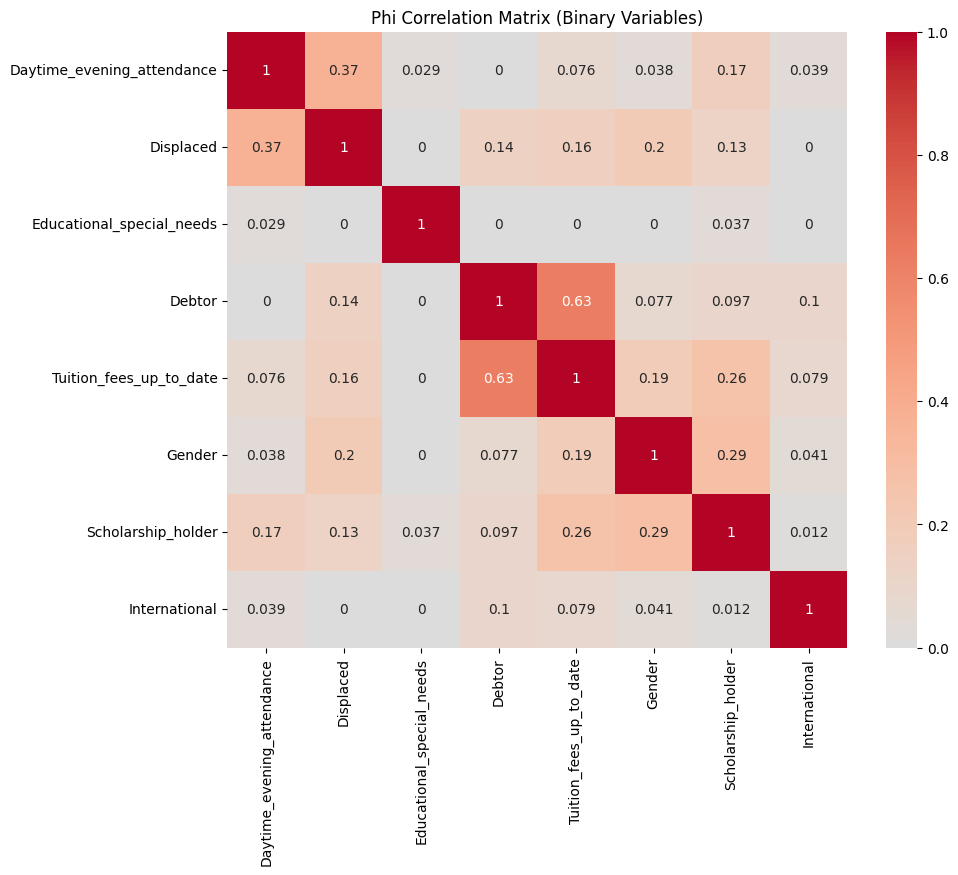

In [36]:
plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Phi Correlation Matrix (Binary Variables)")
plt.show()

<a id='binary_cont'></a>
## 5. Binary vs Continuous Relationship

- To compare binary vs continous variables, we need to complete a point biserial correlation. Over here I created a function to return to us add results.

- Point biserial correlation is another branch of Pearson's correlation with a value between -1 and 1 indicating the strength of the relationship. The closer the number is to 0, the weaker it is.

- All variables seem to have a significant relationship with eachother

In [37]:
results = []

for cont_col in cont_df.columns:
    for bin_col in binary_df.columns:

        temp_df = pd.concat([cont_df[cont_col], binary_df[bin_col]], axis=1)

        if temp_df[bin_col].nunique() == 2:  # Confirm binary
            r, p = stats.pointbiserialr(temp_df[bin_col], temp_df[cont_col])
            
            results.append({
                'Binary Variable': bin_col,
                'Continuous Variable': cont_col,
                'PointBiserial r': r,
                'p_value': p,
                "Significant": p_val < 0.05
            })

# Display as DataFrame
results_df = pd.DataFrame(results)
pd.set_option('display.max_rows', None)
results_df


,Binary Variable,Continuous Variable,PointBiserial r,p_value,Significant
0,Daytime_evening_attendance,Previous_qualification_grade,0.063810,1.195091e-04,True
1,Displaced,Previous_qualification_grade,-0.010238,5.374862e-01,True
2,Educational_special_needs,Previous_qualification_grade,0.009246,5.776178e-01,True
3,Debtor,Previous_qualification_grade,-0.062201,1.769028e-04,True
4,Tuition_fees_up_to_date,Previous_qualification_grade,0.079246,1.749484e-06,True
5,Gender,Previous_qualification_grade,-0.057654,5.102028e-04,True
6,Scholarship_holder,Previous_qualification_grade,0.069054,3.127248e-05,True
7,International,Previous_qualification_grade,0.055494,8.230027e-04,True
8,Daytime_evening_attendance,Admission_grade,0.022325,1.787002e-01,True
9,Displaced,Admission_grade,-0.002023,9.030387e-01,True


<a id='part3'></a>
# Part 3 - Initial Model
<b>Important notes</b>
1. Enrolled students have been dropped in part 1


## Logit
<a id="logit"></a>

### Normal Multinomial Model
Uses scikit 

https://ujangriswanto08.medium.com/hands-on-guide-to-multinomial-logistic-regression-for-students-using-python-449f3e58d0f0
<a id="norm_logit"></a>

#### Creating Model

In [38]:
# Splitting data into training & testing sets

from sklearn.model_selection import train_test_split
X = df.drop("Target", axis = 1)
y = df["Target"]
# double check test size here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [39]:
# Training the model
from sklearn.linear_model import LogisticRegression

# the model

logitmodel = LogisticRegression(multi_class='auto', #change auto to multinomial if you have 3 target variable levels
                                       solver = 'lbfgs',
                                       max_iter= 200)

logitmodel.fit(X_train, y_train)

C:\Users\amann\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\amann\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=200, multi_class='auto')

In [40]:
intercept_lm = logitmodel.intercept_
coef_lm = logitmodel.coef_

# b0 intercept
print(intercept_lm)
# b1 slope
print(coef_lm)


[0.00101143]
[[ 2.07633175e-03  2.27539035e-02 -1.10937143e-02  7.16299505e-04
   3.24281807e-03  3.98458215e-03 -3.88141771e-04  1.05313880e-02
  -1.04584350e-02 -2.77552722e-03 -2.21553525e-03  2.27724906e-04
  -3.33648751e-03  5.34240638e-05  2.02961040e-02 -3.42041311e-02
   2.15096022e-02 -2.87142218e-02  3.71986686e-03 -2.28278290e-04
  -1.74299945e-01 -2.54925185e-01 -6.95013752e-05  3.38564823e-05
  -8.05969223e-05 -2.14612565e-01]]


#### Predictions

In [41]:
y_pred = logitmodel.predict(X_test) #this is what solves the error from the evaluations part

print(y_pred)

[1 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 0 0 1 1 1 0 0 0 0 1
 1 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 1 1 0 0 0 0 0 1 0 1 0 1 0 1 1
 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 1 0 0 1 0 0 1 1 0 0 0 0 1 0 0
 0 0 1 1 0 1 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 1
 0 1 0 1 0 0 1 0 0 1 0 1 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0
 1 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1 1 0 1 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0
 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0
 0 0 1 0 1 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 0 0 0 0 1 0 0 1
 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 0 1 0 0 0 1 1 1 0 0 1 1 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 1 

#### Evaluating Results

- Following this tutorial, https://realpython.com/logistic-regression-python/, accuracy and other metrics don't work for logit
- I tried the same model before dropping enrolled students and it had an score of almost 66%

In [42]:
logitmodel.score(X, y)

0.8228650137741047

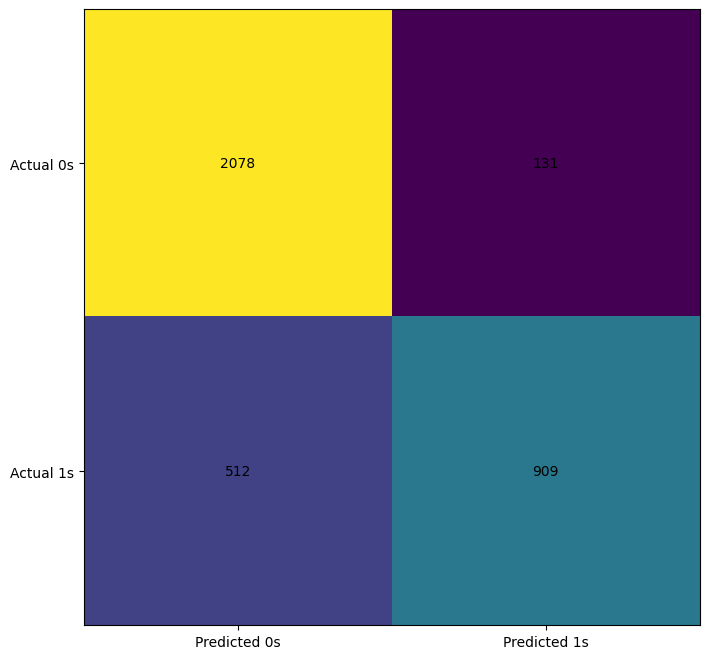

In [43]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y, logitmodel.predict(X))


fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(cm)
ax.grid(False)
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.show()

In [44]:
print(classification_report(y, logitmodel.predict(X)))

              precision    recall  f1-score   support

           0       0.80      0.94      0.87      2209
           1       0.87      0.64      0.74      1421

    accuracy                           0.82      3630
   macro avg       0.84      0.79      0.80      3630
weighted avg       0.83      0.82      0.82      3630



In [45]:
# Example using a single feature column
X_single = df[['first_sem_grade']]  # must be 2D
y = df['Target']

# Fit logistic regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_single, y)

# Predict probabilities of dropout
y_pred = model.predict_proba(X_single)[:, 1]  # probability of class 1 (dropout)


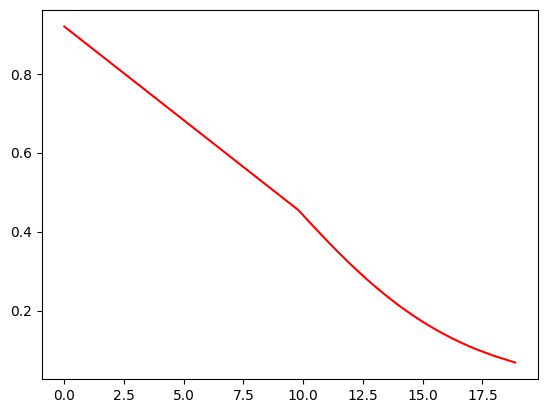

In [46]:
sorted_indices = X_single['first_sem_grade'].argsort()
X_sorted = X_single['first_sem_grade'].values[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

plt.plot(X_sorted, y_pred_sorted, color='red', label="Logistic Curve")


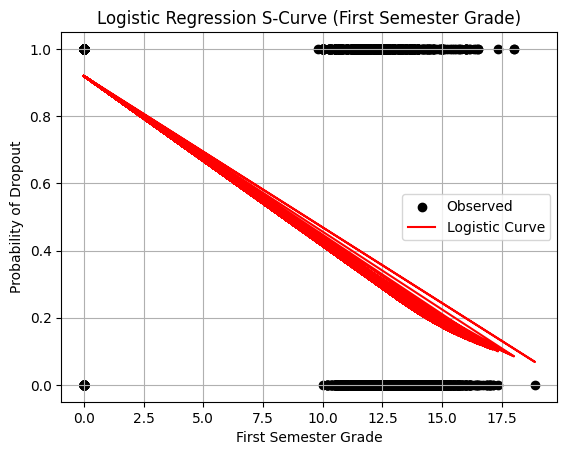

In [47]:
import matplotlib.pyplot as plt

plt.scatter(X_single, y, color='black', label="Observed")
plt.plot(X_single, y_pred, color='red', label="Logistic Curve")
plt.xlabel("First Semester Grade")
plt.ylabel("Probability of Dropout")
plt.title("Logistic Regression S-Curve (First Semester Grade)")
plt.legend()
plt.grid(True)
plt.show()


## Random Forest Classifier

In [48]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image  


In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [50]:
rfmodel = RandomForestClassifier(n_estimators = 100, criterion= 'gini',
                                max_depth=2, random_state=0, 
                                bootstrap=True, oob_score=True)

In [51]:
rfmodel.fit(X_train, y_train)

RandomForestClassifier(max_depth=2, oob_score=True, random_state=0)

#### Evaluating Results

##### Train Data

In [52]:
training_predict = rfmodel.predict(X_train)

In [53]:
print(metrics.classification_report(y_train, training_predict, digits = 3))

              precision    recall  f1-score   support

           0      0.830     0.937     0.880      1760
           1      0.879     0.705     0.782      1144

    accuracy                          0.845      2904
   macro avg      0.854     0.821     0.831      2904
weighted avg      0.849     0.845     0.842      2904



In [54]:
print(metrics.confusion_matrix(y_train, training_predict))

[[1649  111]
 [ 338  806]]


##### Test Data

In [55]:
test_predict = rfmodel.predict(X_test)

In [56]:
print(metrics.classification_report(y_test, test_predict, digits = 3))

              precision    recall  f1-score   support

           0      0.827     0.955     0.886       449
           1      0.903     0.675     0.773       277

    accuracy                          0.848       726
   macro avg      0.865     0.815     0.830       726
weighted avg      0.856     0.848     0.843       726



In [57]:
print(metrics.confusion_matrix(y_test, test_predict))

[[429  20]
 [ 90 187]]


#### Classification Table resources
- https://medium.com/@kennymiyasato/confused-about-the-confusion-matrix-b98a1afb00af
- https://medium.com/@kennymiyasato/classification-report-precision-recall-f1-score-accuracy-16a245a437a5
- https://koopingshung.com/blog/machine-learning-model-selection-accuracy-precision-recall-f1/
- 

In [58]:
# Strongest predictors of the general rf model
# Assuming you've fit the model already as 'rf_model'
importances = rfmodel.feature_importances_
features = X_train.columns
feat_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_importance_df = feat_importance_df.sort_values(by='Importance', ascending=False)
print(feat_importance_df)

                         Feature  Importance
25             Average_Sem_Grade    0.245989
21              second_sem_grade    0.216209
20               first_sem_grade    0.171493
15       Tuition_fees_up_to_date    0.146993
18             Age_at_enrollment    0.091581
17            Scholarship_holder    0.033146
1               Application_mode    0.022327
16                        Gender    0.020973
14                        Debtor    0.020291
11               Admission_grade    0.008930
6   Previous_qualification_grade    0.007065
3                         Course    0.006804
5         Previous_qualification    0.006437
12                     Displaced    0.001113
9             Mothers_occupation    0.000314
2              Application_order    0.000142
7          Mothers_qualification    0.000120
19                 International    0.000064
24                           GDP    0.000009
8          Fathers_qualification    0.000000
0                 Marital_status    0.000000
4     Dayt

In [59]:
import numpy as np
from collections import Counter

# Apply model to get leaf indices for each sample in all trees
leaf_indices = rfmodel.apply(X_test)  # shape: (n_samples, n_trees)

# Convert each sample's path into a tuple for hashing
leaf_signatures = [tuple(row) for row in leaf_indices]

# Count most common profiles (leaf paths)
leaf_counts = Counter(leaf_signatures)
most_common_profiles = leaf_counts.most_common(10)

# Show them
for i, (signature, count) in enumerate(most_common_profiles):
    print(f"Profile #{i+1} - Count: {count} - Leaf Signature: {signature}")


Profile #1 - Count: 11 - Leaf Signature: (np.int64(6), np.int64(3), np.int64(5), np.int64(6), np.int64(5), np.int64(5), np.int64(6), np.int64(3), np.int64(6), np.int64(6), np.int64(6), np.int64(5), np.int64(5), np.int64(6), np.int64(5), np.int64(5), np.int64(6), np.int64(3), np.int64(5), np.int64(3), np.int64(2), np.int64(6), np.int64(3), np.int64(3), np.int64(6), np.int64(3), np.int64(6), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(2), np.int64(3), np.int64(3), np.int64(5), np.int64(3), np.int64(6), np.int64(3), np.int64(5), np.int64(6), np.int64(3), np.int64(2), np.int64(6), np.int64(2), np.int64(6), np.int64(2), np.int64(3), np.int64(6), np.int64(6), np.int64(5), np.int64(3), np.int64(3), np.int64(6), np.int64(5), np.int64(3), np.int64(6), np.int64(2), np.int64(2), np.int64(6), np.int64(6), np.int64(5), np.int64(2), np.int64(2), np.int64(2), np.int64(6), np.int64(5), np.int64(5), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(

In [60]:
from sklearn.cluster import KMeans

# Use the leaf indices as features
leaf_features = rfmodel.apply(X_test)

# Cluster them (e.g., into 5 groups)
kmeans = KMeans(n_clusters=5, random_state=0)
cluster_labels = kmeans.fit_predict(leaf_features)

# Now each sample has a cluster/profile label
X_test_clustered = X_test.copy()
X_test_clustered['Cluster'] = cluster_labels


In [61]:
from sklearn.tree import export_text

tree_structures = [export_text(tree, feature_names=X.columns.tolist()) for tree in rfmodel.estimators_]
structure_counts = Counter(tree_structures)
most_common_trees = structure_counts.most_common(5)

for i, (tree_text, count) in enumerate(most_common_trees):
    print(f"\nTree #{i+1} repeated {count} times:\n{tree_text}")



Tree #1 repeated 1 times:
|--- first_sem_grade <= 10.08
|   |--- Displaced <= 0.50
|   |   |--- class: 1.0
|   |--- Displaced >  0.50
|   |   |--- class: 1.0
|--- first_sem_grade >  10.08
|   |--- Tuition_fees_up_to_date <= 0.50
|   |   |--- class: 1.0
|   |--- Tuition_fees_up_to_date >  0.50
|   |   |--- class: 0.0


Tree #2 repeated 1 times:
|--- Application_mode <= 22.50
|   |--- Average_Sem_Grade <= 11.07
|   |   |--- class: 1.0
|   |--- Average_Sem_Grade >  11.07
|   |   |--- class: 0.0
|--- Application_mode >  22.50
|   |--- Tuition_fees_up_to_date <= 0.50
|   |   |--- class: 1.0
|   |--- Tuition_fees_up_to_date >  0.50
|   |   |--- class: 0.0


Tree #3 repeated 1 times:
|--- Tuition_fees_up_to_date <= 0.50
|   |--- International <= 0.50
|   |   |--- class: 1.0
|   |--- International >  0.50
|   |   |--- class: 1.0
|--- Tuition_fees_up_to_date >  0.50
|   |--- Application_mode <= 22.00
|   |   |--- class: 0.0
|   |--- Application_mode >  22.00
|   |   |--- class: 0.0


Tree #4 r

In [62]:
# Apply rfmodel to training or test data (X should not contain the target)
leaf_matrix = rfmodel.apply(X)  # shape = (n_samples, n_trees)


In [63]:
from sklearn.cluster import KMeans

# Choose how many clusters you want (e.g., 4 profiles)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(leaf_matrix)

# Add cluster labels to your dataframe
X_clustered = X.copy()
X_clustered['Cluster'] = cluster_labels


<a id='part4'></a>
# Part 4 - Model Improvement

By using:
* Preventing the dummy variable trap
* VIF
* Interaction Terms (For Logit only)


## Removing Dummy Variable Trap (for regression only)

In [64]:
# Create an empty DataFrame to collect all dummies
dummies_df = pd.DataFrame(index=df.index)

# Loop through each nominal variable and create dummy variables
for nominal_var in nominal_df.columns:
    dummies = pd.get_dummies(df[nominal_var], prefix=nominal_var, drop_first=True)  # drop_first avoids dummy variable trap
    dummies_df = pd.concat([dummies_df, dummies], axis=1)

# Drop original nominal variables from df
df_no_nominals = df.drop(columns=nominal_df.columns)

# Concatenate the dummies with the cleaned df
regression_df = pd.concat([df_no_nominals, dummies_df], axis=1)


### Testing out logit model with same variables

In [65]:
from sklearn.model_selection import train_test_split
X = regression_df.drop("Target", axis = 1) #used regression df from prev. part
y = regression_df["Target"]
# double check test size here
X_train_logit, X_test_logit, y_train_logit, y_test_logit = train_test_split(X, y, test_size=0.2, random_state=42)


In [66]:

logitmodel = LogisticRegression(multi_class='auto', #change auto to multinomial if you have 3 target variable levels
                                       solver = 'lbfgs',
                                       max_iter= 200)

logitmodel.fit(X_train_logit, y_train_logit)

C:\Users\amann\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\amann\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=200, multi_class='auto')

Model fit is similar to the original one of 82.4%

In [67]:
logitmodel.score(X, y)

0.8878787878787879

<a id='VIF'></a>
## Removing Multicollinearity


Highly correlated variables are Course, daytime evening attendance, previous qualification grade, admission grade, tuition fees up to date, age at enrollment, grades

In [68]:
# Using VIF function

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = df.columns

vif_data["VIF"] = [variance_inflation_factor(df.values, i)
                     for i in range(len(df.columns))]

print(vif_data)

C:\Users\amann\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                         feature         VIF
0                 Marital_status    6.318009
1               Application_mode    3.820476
2              Application_order    3.283157
3                         Course   24.472883
4     Daytime_evening_attendance   10.752105
5         Previous_qualification    1.561889
6   Previous_qualification_grade  156.823182
7          Mothers_qualification    4.085275
8          Fathers_qualification    4.651787
9             Mothers_occupation    5.633390
10            Fathers_occupation    5.741772
11               Admission_grade  375.491644
12                     Displaced    2.866073
13     Educational_special_needs    1.019972
14                        Debtor    1.458524
15       Tuition_fees_up_to_date   10.787612
16                        Gender    1.759693
17            Scholarship_holder    1.612866
18             Age_at_enrollment  234.164098
19                 International    1.048633
20               first_sem_grade         inf
21        

### Logit Model

No Improvement from 88.7% --> 87.13%

In [69]:
from sklearn.model_selection import train_test_split
X = regression_df.drop(["Previous_qualification_grade", 
                        "Admission_grade",
                        "Age_at_enrollment",
                        "Target",
                        "Daytime_evening_attendance",
                        "Tuition_fees_up_to_date",
                        "Unemployment_rate"], axis = 1) #used regression df from prev. part
y = regression_df["Target"]
# double check test size here
X_train_logit, X_test_logit, y_train_logit, y_test_logit = train_test_split(X, y, test_size=0.2, random_state=42)


In [70]:

logitmodel = LogisticRegression(multi_class='auto', #change auto to multinomial if you have 3 target variable levels
                                       solver = 'lbfgs',
                                       max_iter= 200)

logitmodel.fit(X_train_logit, y_train_logit)

C:\Users\amann\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=200, multi_class='auto')

In [71]:
logitmodel.score(X, y)


0.8716253443526171

### Random Forest Classifier
No significant improvement

In [72]:
from sklearn.model_selection import train_test_split
X = df.drop(["Previous_qualification_grade", 
                        "Admission_grade",
                        "Age_at_enrollment",
                        "Target"], axis = 1) #used regression df from prev. part
y = df["Target"]
# double check test size here
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42)


In [73]:
rfmodel = RandomForestClassifier(n_estimators = 100, criterion= 'gini',
                                max_depth=2, random_state=0, 
                                bootstrap=True, oob_score=True)

In [74]:
rfmodel.fit(X_train_rf, y_train_rf)

RandomForestClassifier(max_depth=2, oob_score=True, random_state=0)

In [75]:
training_predict = rfmodel.predict(X_train_rf)

In [76]:
print(metrics.classification_report(y_train_rf, training_predict, digits = 3))

              precision    recall  f1-score   support

           0      0.824     0.933     0.875      1760
           1      0.870     0.693     0.772      1144

    accuracy                          0.838      2904
   macro avg      0.847     0.813     0.823      2904
weighted avg      0.842     0.838     0.834      2904



In [77]:
print(metrics.confusion_matrix(y_train_rf, training_predict))

[[1642  118]
 [ 351  793]]


In [78]:
test_predict = rfmodel.predict(X_test_rf)


In [79]:
print(metrics.classification_report(y_test_rf, test_predict, digits = 3))


              precision    recall  f1-score   support

           0      0.822     0.949     0.881       449
           1      0.889     0.668     0.763       277

    accuracy                          0.842       726
   macro avg      0.856     0.808     0.822       726
weighted avg      0.848     0.842     0.836       726



In [80]:
print(metrics.confusion_matrix(y_test_rf, test_predict))

[[426  23]
 [ 92 185]]


### Random Forest Classifier (test 2)

Model has improved from 83.9% accuracy to 84.3% by changing the n_estimators to 200

In [81]:
from sklearn.model_selection import train_test_split
X = df.drop(["Previous_qualification_grade", 
                        "Admission_grade",
                        "Age_at_enrollment",
                        "Target"], axis = 1) #used regression df from prev. part
y = df["Target"]
# double check test size here
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42)


In [82]:
rfmodel = RandomForestClassifier(n_estimators = 200, criterion= 'gini',
                                max_depth=2, random_state=0, 
                                bootstrap=True, oob_score=True)

In [83]:
rfmodel.fit(X_train_rf, y_train_rf)

RandomForestClassifier(max_depth=2, n_estimators=200, oob_score=True,
                       random_state=0)

In [84]:
training_predict = rfmodel.predict(X_train_rf)

In [85]:
print(metrics.classification_report(y_train_rf, training_predict, digits = 3))

              precision    recall  f1-score   support

           0      0.826     0.936     0.878      1760
           1      0.877     0.696     0.776      1144

    accuracy                          0.842      2904
   macro avg      0.851     0.816     0.827      2904
weighted avg      0.846     0.842     0.837      2904



In [86]:
print(metrics.confusion_matrix(y_train_rf, training_predict))

[[1648  112]
 [ 348  796]]


In [87]:
test_predict = rfmodel.predict(X_test_rf)


In [88]:
print(metrics.classification_report(y_test_rf, test_predict, digits = 3))


              precision    recall  f1-score   support

           0      0.820     0.951     0.880       449
           1      0.893     0.661     0.759       277

    accuracy                          0.840       726
   macro avg      0.856     0.806     0.820       726
weighted avg      0.847     0.840     0.834       726



In [89]:
print(metrics.confusion_matrix(y_test_rf, test_predict))

[[427  22]
 [ 94 183]]


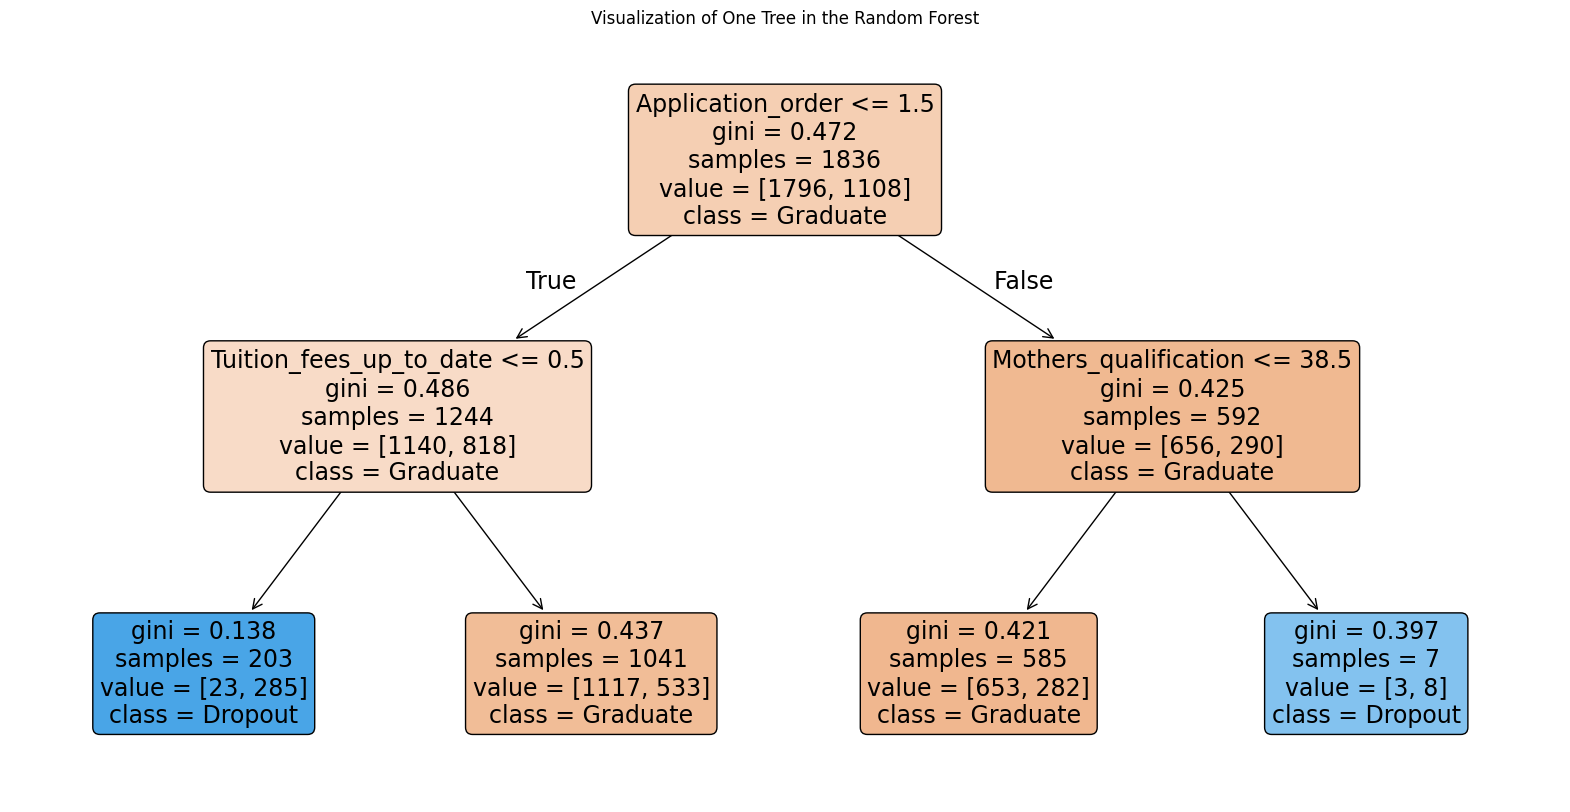

In [90]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Select one tree from the random forest
tree_to_plot = rfmodel.estimators_[0]

# Use the actual feature names and class labels
feature_names = X.columns.tolist()
class_names = ['Graduate', 'Dropout']  # Adjust based on your actual target classes

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(tree_to_plot,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          max_depth=3)  # Optional: limit depth for readability
plt.title("Visualization of One Tree in the Random Forest")
plt.show()



## Engineering features

### Logit

Improvement from 86.25% to 86.94%

In [91]:
from sklearn.model_selection import train_test_split
X = regression_df.drop(["Previous_qualification_grade", 
                        "Admission_grade",
                        "Age_at_enrollment",
                        "Target",
                        "Daytime_evening_attendance",
                        "Tuition_fees_up_to_date",
                        "Unemployment_rate"], axis = 1)
y = regression_df["Target"]
# double check test size here
X_train_logit, X_test_logit, y_train_logit, y_test_logit = train_test_split(X, y, test_size=0.2, random_state=42)


In [92]:
'grade_change' in X.columns


False

In [93]:
print(regression_df.columns.tolist())


['Daytime_evening_attendance', 'Previous_qualification_grade', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'first_sem_grade', 'second_sem_grade', 'Unemployment_rate', 'Inflation_rate', 'GDP', 'Target', 'Average_Sem_Grade', 'Marital_status_2', 'Marital_status_3', 'Marital_status_4', 'Marital_status_5', 'Marital_status_6', 'Application_mode_2', 'Application_mode_5', 'Application_mode_7', 'Application_mode_10', 'Application_mode_15', 'Application_mode_16', 'Application_mode_17', 'Application_mode_18', 'Application_mode_26', 'Application_mode_27', 'Application_mode_39', 'Application_mode_42', 'Application_mode_43', 'Application_mode_44', 'Application_mode_51', 'Application_mode_53', 'Application_mode_57', 'Application_order_1', 'Application_order_2', 'Application_order_3', 'Application_order_4', 'Application_order_5', 'Application_order_6', 'Course_171', 'Course_8014'

In [94]:

logitmodel = LogisticRegression(multi_class='auto', #change auto to multinomial if you have 3 target variable levels
                                       solver = 'lbfgs',
                                       penalty= 'l2',
                                       max_iter= 200)

logitmodel.fit(X_train_logit, y_train_logit)

C:\Users\amann\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=200, multi_class='auto')

In [95]:
logitmodel.score(X, y)


0.8716253443526171

## Checking the AUC of the ROC plot

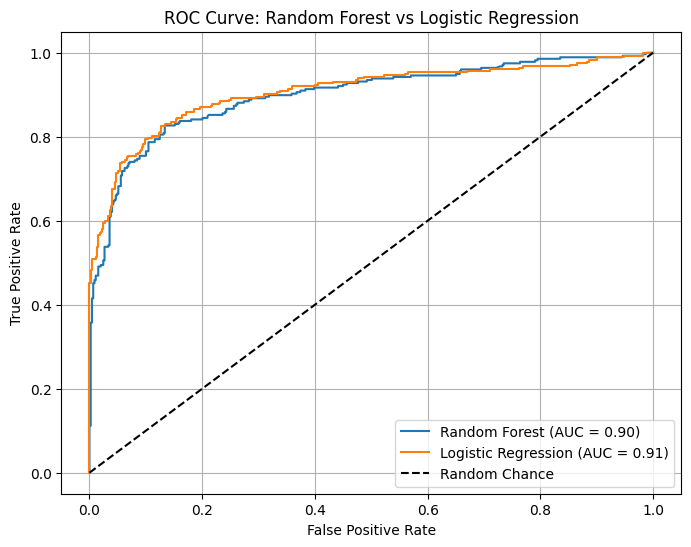

In [96]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assume these are your fitted models
# rf_model = RandomForestClassifier(...)
# logit_model = LogisticRegression(...)

# And you have X_test and y_test from train_test_split
# X_train, X_test, y_train, y_test = ...

# Get predicted probabilities
rf_probs = rfmodel.predict_proba(X_test_rf)[:, 1]
logit_probs = logitmodel.predict_proba(X_test_logit)[:, 1]

# Compute ROC curve and AUC
rf_fpr, rf_tpr, _ = roc_curve(y_test_rf, rf_probs)
rf_auc = auc(rf_fpr, rf_tpr)

logit_fpr, logit_tpr, _ = roc_curve(y_test_logit, logit_probs)
logit_auc = auc(logit_fpr, logit_tpr)

# Plot the ROC curves
plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(logit_fpr, logit_tpr, label=f'Logistic Regression (AUC = {logit_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Random Forest vs Logistic Regression')
plt.legend(loc='lower right')
plt.grid()
plt.show()


## PCA

In [97]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Standardize the features (important for PCA!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_logit)
X_test_scaled = scaler.transform(X_test_logit)


In [98]:

# Step 2: Apply PCA (keep enough components to explain ~95% of variance)
pca = PCA(n_components=0.95)  # keeps enough components to explain 95% of variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


In [99]:

# Optional: Check how many components were retained
print(f"Original features: {X.shape[1]}")
print(f"Reduced to PCA components: {X_train_pca.shape[1]}")


Original features: 201
Reduced to PCA components: 150


In [100]:
pca = PCA(n_components= 8)


In [101]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_logit)
X_test_scaled = scaler.transform(X_test_logit)

# Apply PCA with 5 components
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Check PCA output shape
print("PCA-transformed training shape:", X_train_pca.shape)  # Should be (rows, 5)


PCA-transformed training shape: (2904, 10)


In [102]:
logit_pca_model = LogisticRegression()
logit_pca_model.fit(X_train_pca, y_train_logit)
y_pred_pca = logit_pca_model.predict(X_test_pca)


In [103]:
print(y_pred_pca)

[0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 1 1 1 0 0 0 0 1
 1 1 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 1 0 0 0 0 0 0 1 0 1 0 1 1 0 1
 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 1
 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 1
 0 1 0 0 1 0 0 0 0 1 0 1 0 1 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0
 1 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 1 0 0 0 0 0 1 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0
 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 1 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0
 0 0 1 0 1 1 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0
 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 1 0 0 1 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0
 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 0 1 0 0 1 1 1 1 0 0 1 1 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 1 

In [104]:
y_pred_proba_pca = logit_pca_model.predict_proba(X_test_pca)[:, 1]  # probability of class 1
print(y_pred_proba_pca)

[0.30741333 0.16659377 0.6684252  0.09818057 0.93693414 0.15184229
 0.40999578 0.3981932  0.18485466 0.8551338  0.39260744 0.08184501
 0.23637762 0.06470072 0.30513125 0.43480494 0.96863335 0.94690274
 0.09918222 0.25279823 0.42040656 0.17540143 0.30480343 0.19929101
 0.99376576 0.7572833  0.13682693 0.26617903 0.29529772 0.93474098
 0.9653879  0.95008648 0.30541203 0.19281883 0.4044379  0.17943322
 0.94111075 0.5417213  0.58163993 0.22572413 0.9467505  0.11354037
 0.35919358 0.37734014 0.96636196 0.17822846 0.9728758  0.24319344
 0.25342549 0.41466614 0.95761991 0.17205069 0.22166622 0.36148146
 0.52410239 0.27512431 0.82454668 0.54534706 0.45618371 0.59479144
 0.42243975 0.15805453 0.16740439 0.09640096 0.13971873 0.45048566
 0.98557559 0.21570252 0.95719251 0.34161104 0.96993417 0.71323355
 0.45217213 0.50728544 0.1247593  0.27214695 0.27152165 0.1798038
 0.32972591 0.80100727 0.91260564 0.14982759 0.12749624 0.12159487
 0.36273858 0.13903218 0.36684063 0.87301166 0.24250169 0.40815

In [105]:
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
# Accuracy
accuracy = accuracy_score(y_test_logit, y_pred_pca)
print(f"Accuracy (PCA + Logit): {accuracy:.4f}")

Accuracy (PCA + Logit): 0.8058


AUC (PCA + Logit): 0.8627


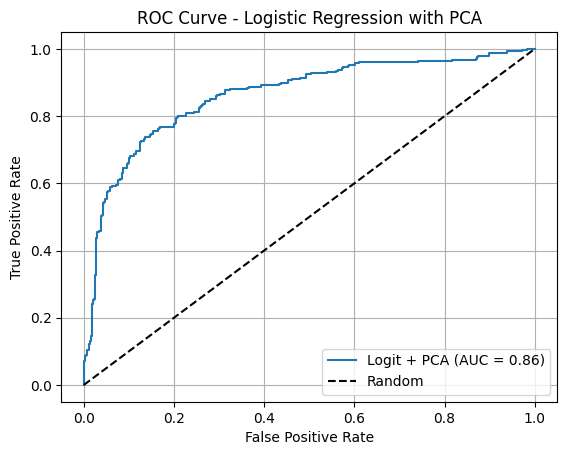

In [106]:
# ROC AUC
auc_score = roc_auc_score(y_test_logit, y_pred_proba_pca)
print(f"AUC (PCA + Logit): {auc_score:.4f}")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test_logit, y_pred_proba_pca)

plt.figure()
plt.plot(fpr, tpr, label=f"Logit + PCA (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression with PCA")
plt.legend()
plt.grid(True)
plt.show()


In [107]:
print(X_train_pca.shape[1])  # should print 5


10


# Part 5 - Seperated dimensions

1st: Logistic Regression Model
0.6517906336088154
              precision    recall  f1-score   support

           0       0.70      0.74      0.72      2209
           1       0.56      0.52      0.54      1421

    accuracy                           0.65      3630
   macro avg       0.63      0.63      0.63      3630
weighted avg       0.65      0.65      0.65      3630



C:\Users\amann\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


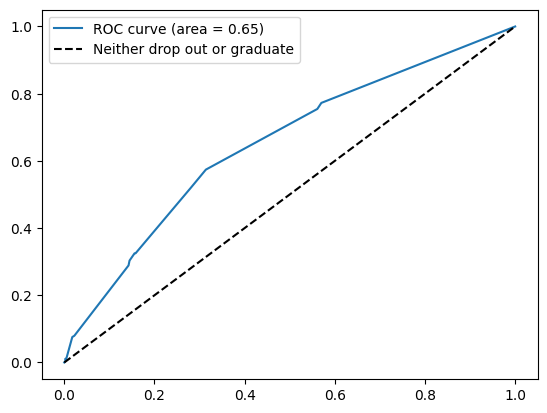

In [108]:
# Demographics : includes gender, marital_status, international, displaced

    # Seperating dimensions

demographics = ['Marital_status', 'Gender', 'Displaced', 'Target' ]
df_demographics = df[demographics]

# Logistic model
print("1st: Logistic Regression Model")
X = df_demographics.drop('Target', axis = 1) #used regression df from prev. part
y = df_demographics['Target']

# double check test size here
X_train_logit, X_test_logit, y_train_logit, y_test_logit = train_test_split(X, y, test_size=0.2, random_state=42)

# Fitting model and required metrics
demo_model_logit = LogisticRegression(multi_class='auto',
                                       solver = 'lbfgs',
                                       max_iter= 200)

demo_model_logit.fit(X_train_logit, y_train_logit)
print(demo_model_logit.score(X, y))
print(classification_report(y, demo_model_logit.predict(X)))



demo_logit_probs = demo_model_logit.predict_proba(X_test_logit)[:, 1]

#ROC plot
demographics_fpr, demographics_tpr, _ = roc_curve(y_test_logit, demo_logit_probs)
demographics_auc = auc(demographics_fpr, demographics_tpr)
plt.plot(demographics_fpr, demographics_tpr, label='ROC curve (area = %0.2f)' % demographics_auc)
plt.plot([0, 1], [0, 1], 'k--', label='Neither drop out or graduate')
plt.legend()
plt.show()

In [109]:
print(list(zip(demo_model_logit.coef_[0], X.columns)))
print(demo_model_logit.intercept_)


[(np.float64(0.2673592554757338), 'Marital_status'), (np.float64(1.0624482982978878), 'Gender'), (np.float64(-0.35178260406811984), 'Displaced')]
[-0.94383335]


In [110]:
# Get the intercept
intercept = demo_model_logit.intercept_
coefficient = demo_model_logit.coef_

print(f"Intercept: {intercept}")
print(f"Coefficient: {coefficient}")

Intercept: [-0.94383335]
Coefficient: [[ 0.26735926  1.0624483  -0.3517826 ]]


2nd: Random Forest Model
0.6506887052341598
              precision    recall  f1-score   support

           0       0.66      0.87      0.75      2209
           1       0.61      0.30      0.41      1421

    accuracy                           0.65      3630
   macro avg       0.63      0.59      0.58      3630
weighted avg       0.64      0.65      0.62      3630



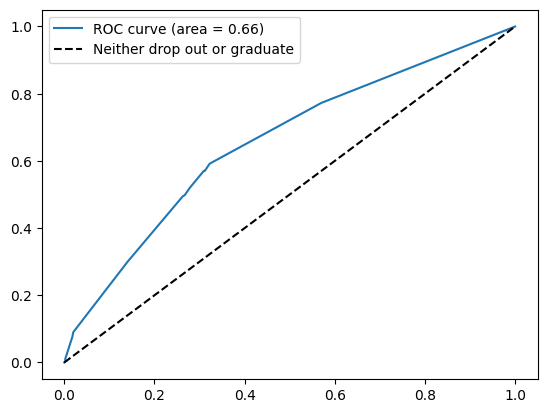

In [111]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42)

print("2nd: Random Forest Model")

dem_model_rf = RandomForestClassifier(n_estimators = 100, criterion= 'gini',
                                max_depth=2, random_state=0, 
                                bootstrap=True, oob_score=True)
dem_model_rf.fit(X_train_rf, y_train_rf)

print(dem_model_rf.score(X, y))
print(classification_report(y, dem_model_rf.predict(X)))

dem_rf_probs = dem_model_rf.predict_proba(X_test_rf)[:, 1]
#ROC plot
demographics_fpr, demographics_tpr, _ = roc_curve(y_test_rf, dem_rf_probs)
demographics_auc = auc(demographics_fpr, demographics_tpr)
plt.plot(demographics_fpr, demographics_tpr, label='ROC curve (area = %0.2f)' % demographics_auc)
plt.plot([0, 1], [0, 1], 'k--', label='Neither drop out or graduate')
plt.legend()
plt.show()

In [112]:
# Strongest predictors of the demographic logistic model

# Assuming you've fit the model
importances = dem_model_rf.feature_importances_
features = X_train_rf.columns
feat_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_importance_df = feat_importance_df.sort_values(by='Importance', ascending=False)
print(feat_importance_df)

          Feature  Importance
1          Gender    0.608945
2       Displaced    0.211642
0  Marital_status    0.179412


In [113]:
# Group by Gender and get dropout counts
gender_dropout_counts = df.groupby('Gender')['Target'].value_counts().unstack()

# Rename columns for clarity
gender_dropout_counts.columns = ['Graduated', 'Dropped out']

# Calculate dropout rate for each gender
gender_dropout_counts['Dropout Rate (%)'] = (gender_dropout_counts['Dropped out'] /
                                             (gender_dropout_counts['Graduated'] + gender_dropout_counts['Dropped out'])) * 100

print(gender_dropout_counts)


# Group by Marital status and get dropout counts
marital_dropout_counts = df.groupby('Marital_status')['Target'].value_counts().unstack()

# Rename columns for clarity
marital_dropout_counts.columns = ['Married', 'Dropped out']

# Calculate dropout rate for each gender
marital_dropout_counts['Dropout Rate (%)'] = (marital_dropout_counts['Dropped out'] /
                                             (marital_dropout_counts['Married'] + marital_dropout_counts['Dropped out'])) * 100

print(marital_dropout_counts)

# Group by Displaced status and get dropout counts
displaced_dropout_counts = df.groupby('Displaced')['Target'].value_counts().unstack()

# Rename columns for clarity
displaced_dropout_counts.columns = ['Displaced', 'Dropped out']

# Calculate dropout rate for each gender
displaced_dropout_counts['Dropout Rate (%)'] = (displaced_dropout_counts['Dropped out'] /
                                             (displaced_dropout_counts['Displaced'] + displaced_dropout_counts['Dropped out'])) * 100

print(displaced_dropout_counts)

        Graduated  Dropped out  Dropout Rate (%)
Gender                                          
0            1661          720         30.239395
1             548          701         56.124900


                Married  Dropped out  Dropout Rate (%)
Marital_status                                        
1                  2015         1184         37.011566
2                   148          179         54.740061
3                     1            1         50.000000
4                    33           42         56.000000
5                    11           11         50.000000
6                     1            4         80.000000
           Displaced  Dropped out  Dropout Rate (%)
Displaced                                          
0                885          752         45.937691
1               1324          669         33.567486


In [114]:
df['Target'] == 1

0        True
1       False
2        True
3       False
4       False
5       False
6       False
7        True
8       False
9        True
10      False
11      False
12       True
13      False
14      False
15       True
17      False
18      False
20      False
22      False
23      False
24      False
26      False
28      False
31      False
33      False
34      False
35       True
36       True
37       True
38      False
39       True
40       True
41      False
42      False
43       True
44       True
46      False
47      False
48      False
49      False
50      False
53      False
54       True
55      False
56       True
57       True
58      False
60      False
61      False
65       True
66      False
67      False
68       True
71      False
72       True
73       True
74      False
75       True
76       True
77      False
78      False
79      False
80       True
81       True
82       True
84      False
85      False
86      False
87      False
90       True
91    

# 6- Trying out stuff

Reference: <br>
dropout_graduated_df = student_data[student_data['Target'].isin(['Dropout', 'Graduate'])] <br>
enrolled_df = student_data[student_data['Target'] == 'Enrolled'] <br>
<br>
0 = grad, 1 = dropout

In [115]:
# 1 – single 2 – married 3 – widower 4 – divorced 5 – facto union 6 – legally separated
single_graduate = df[df['Marital_status'] == 1 ] 
married_graduate = df[df['Marital_status'] !=1]

not_displaced_graduate = df[df['Displaced'] == 0]
displaced_graduate = df[df['Displaced'] == 1]

female_graduate = df[df['Gender'] == 0]
male_graduate = df[df["Gender"] == 1]

In [116]:
print(single_graduate.head())

   Marital_status  Application_mode  Application_order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
6               1                 1                  1    9500   

   Daytime_evening_attendance  Previous_qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
6                           1                       1   

   Previous_qualification_grade  Mothers_qualification  Fathers_qualification  \
0                         122.0                     19                     12   
1                         160.0                      1                      3   
2                

In [117]:
# Splitting data into training & testing sets
from sklearn.model_selection import train_test_split
X = single_graduate.drop("Target", axis = 1)
y = single_graduate["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(n_estimators=500, random_state=42)

rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print("\n")
print(classification_report(y_test, y_pred))
print("\n")


# Get feature importance
features = X_train.columns
importances = rf_classifier.feature_importances_
indices = np.argsort(importances)[::-1]
top_features = pd.DataFrame({
'Feature': features[indices],
'Importance': importances[indices]
 })
    
print("\nTop 10 most important features:")
print(top_features.head(10))

Accuracy: 0.88125


              precision    recall  f1-score   support

           0       0.88      0.94      0.91       401
           1       0.88      0.79      0.83       239

    accuracy                           0.88       640
   macro avg       0.88      0.86      0.87       640
weighted avg       0.88      0.88      0.88       640




Top 10 most important features:
                        Feature  Importance
0              second_sem_grade    0.184624
1             Average_Sem_Grade    0.175490
2               first_sem_grade    0.116844
3       Tuition_fees_up_to_date    0.070110
4             Age_at_enrollment    0.051276
5                        Course    0.046964
6               Admission_grade    0.044204
7  Previous_qualification_grade    0.038313
8            Scholarship_holder    0.026331
9            Fathers_occupation    0.025713


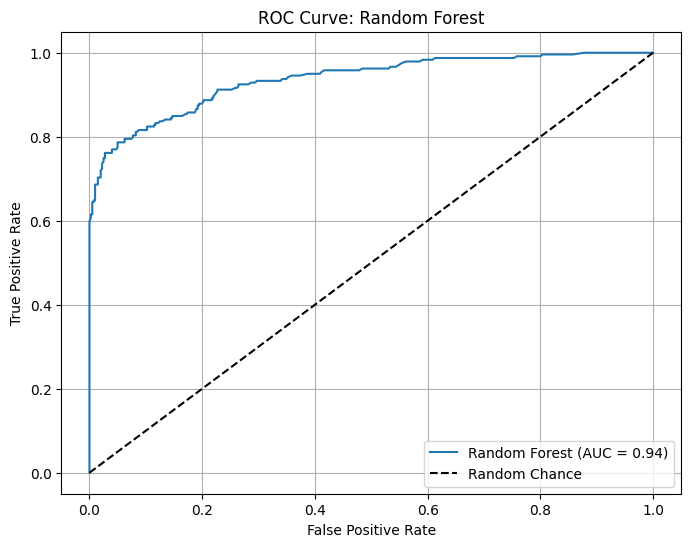

In [118]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assume these are your fitted models
# rf_model = RandomForestClassifier(...)
# logit_model = LogisticRegression(...)

# And you have X_test and y_test from train_test_split
# X_train, X_test, y_train, y_test = ...

# Get predicted probabilities
rf_probs = rf_classifier.predict_proba(X_test)[:, 1]
# logit_probs = logitmodel.predict_proba(X_test)[:, 1]

#  Compute ROC curve and AUC
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc = auc(rf_fpr, rf_tpr)

# logit_fpr, logit_tpr, _ = roc_curve(y_test, logit_probs)
# logit_auc = auc(logit_fpr, logit_tpr)

# Plot the ROC curves
plt.figure(figsize=(8, 6))
# plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
# plt.plot(logit_fpr, logit_tpr, label=f'Logistic Regression (AUC = {logit_auc:.2f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Random Forest')
plt.legend(loc='lower right')
plt.grid()
plt.show()


In [119]:
# Splitting data into training & testing sets
from sklearn.model_selection import train_test_split
X = single_graduate.drop("Target", axis = 1)
y = single_graduate["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


logitmodel = LogisticRegression(multi_class='auto', #change auto to multinomial if you have 3 target variable levels
                                       solver = 'lbfgs',
                                       max_iter= 200)

logitmodel.fit(X_train, y_train)

model_score = logitmodel.score(X, y)
print(model_score)
print("\n")

0.8274460768990309




C:\Users\amann\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\amann\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


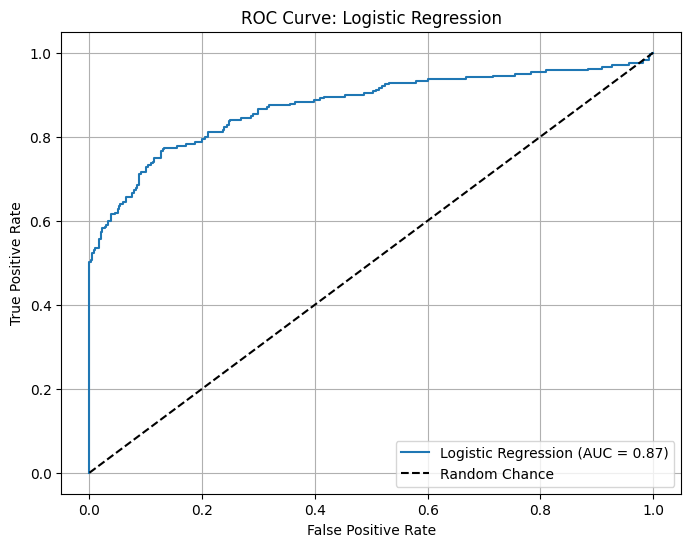

In [120]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assume these are your fitted models
# rf_model = RandomForestClassifier(...)
# logit_model = LogisticRegression(...)

# And you have X_test and y_test from train_test_split
# X_train, X_test, y_train, y_test = ...

# Get predicted probabilities
# rf_probs = rf_classifier.predict_proba(X_test_rf)[:, 1]
logit_probs = logitmodel.predict_proba(X_test)[:, 1]

#  Compute ROC curve and AUC
# rf_fpr, rf_tpr, _ = roc_curve(y_test_rf, rf_probs)
# rf_auc = auc(rf_fpr, rf_tpr)

logit_fpr, logit_tpr, _ = roc_curve(y_test, logit_probs)
logit_auc = auc(logit_fpr, logit_tpr)

# Plot the ROC curves
plt.figure(figsize=(8, 6))
# plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(logit_fpr, logit_tpr, label=f'Logistic Regression (AUC = {logit_auc:.2f})')
# plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Logistic Regression')
plt.legend(loc='lower right')
plt.grid()
plt.show()


In [121]:
# Using VIF function

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = df.columns

vif_data["VIF"] = [variance_inflation_factor(df.values, i)
                     for i in range(len(df.columns))]

print(vif_data)

                         feature         VIF
0                 Marital_status    6.318009
1               Application_mode    3.820476
2              Application_order    3.283157
3                         Course   24.472883
4     Daytime_evening_attendance   10.752105
5         Previous_qualification    1.561889
6   Previous_qualification_grade  156.823182
7          Mothers_qualification    4.085275
8          Fathers_qualification    4.651787
9             Mothers_occupation    5.633390
10            Fathers_occupation    5.741772
11               Admission_grade  375.491644
12                     Displaced    2.866073
13     Educational_special_needs    1.019972
14                        Debtor    1.458524
15       Tuition_fees_up_to_date   10.787612
16                        Gender    1.759693
17            Scholarship_holder    1.612866
18             Age_at_enrollment  234.164098
19                 International    1.048633
20               first_sem_grade         inf
21        

C:\Users\amann\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
